# Examples of using the icechunks

In [1]:
# Required packages; need earthaccess > 18
!pip install -qU icechunk earthaccess cartopy

In [2]:
# need v 18
import earthaccess
earthaccess.__version__

'0.18.0'

## PACE Icechunks

There are the following Icechunk stores:
* `PACE_OCI_L3M_CHL`
* `PACE_OCI_L3M_RRS`

Each L3 product has daily, monthly, and 8D at 2 different grids 0p1deg and 4km. The group names are: 
* `daily/0p1deg` `daily/4km`
* `monthly/0p1deg` `monthly/4km`
* `8Day/0p1deg` `8Day/4km`

The `PACE_OCI_L3M_CHL` daily groups are separated into subgroups based on differences in chunking before 2026-02 and afterwards.
* `daily/0p1deg/chunks_512` +  `daily/0p1deg/chunks_16` and `daily/4km/chunks_512` +  `daily/4km/chunks_16`

These subgroups need to be merged after reading. See examples.

## Function to read the PACE icechunk

We need to pass in EDL tokens to be able to open our store. Your compute needs to be in AWS us-west-2 (e.g. CryoCloud) for the inregion icechunks.

In [1]:
import earthaccess
import icechunk as ic
import xarray as xr

def create_ds(
    product="PACE_OCI_L3M_RRS",
    group="daily/0p1deg",
):
    url = f"https://data.source.coop/fish-pace/pace-oci/inregion/{product}"
    
    storage = ic.http_storage(url)
    
    auth = earthaccess.login()
    s3_credentials = auth.get_s3_credentials(daac="OBDAAC")
    
    url_prefix = "s3://ob-cumulus-prod-public/"
    
    virtual_creds = ic.credentials.containers_credentials({
        url_prefix: ic.credentials.s3_credentials(
            access_key_id=s3_credentials["accessKeyId"],
            secret_access_key=s3_credentials["secretAccessKey"],
            session_token=s3_credentials["sessionToken"],
        )
    })
    
    store = repo = ic.Repository.open(
        storage,
        authorize_virtual_chunk_access=virtual_creds,
    ).readonly_session("main").store

    ds = xr.open_zarr(
        store,
        consolidated=False,
        group=group,
    )

    return ds

## PACE RRS

In [6]:
%%time

ds = create_ds("PACE_OCI_L3M_RRS", "daily/0p1deg")
ds

CPU times: user 307 ms, sys: 105 ms, total: 412 ms
Wall time: 2.65 s


<xarray.Dataset> Size: 6TB
Dimensions:     (time: 710, lat: 1800, lon: 3600, wavelength: 172, rgb: 3,
                 eightbitcolor: 256)
Coordinates:
  * time        (time) datetime64[ns] 6kB 2024-03-05 2024-03-06 ... 2026-02-28
  * lat         (lat) float32 7kB 89.95 89.85 89.75 ... -89.75 -89.85 -89.95
  * lon         (lon) float32 14kB -179.9 -179.9 -179.8 ... 179.8 179.9 180.0
  * wavelength  (wavelength) float64 1kB 346.0 348.0 351.0 ... 714.0 717.0 719.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    Rrs         (time, lat, lon, wavelength) float64 6TB dask.array<chunksize=(1, 16, 1024, 8), meta=np.ndarray>
    palette     (time, rgb, eightbitcolor) uint8 545kB dask.array<chunksize=(1, 3, 256), meta=np.ndarray>
Attributes: (12/64)
    product_name:                      PACE_OCI.20260228.L3m.DAY.RRS.V3_1.Rrs...
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    identifier_product_doi:            10.5067/PACE/OCI/L3M/RRS/3.1
    keywords:                          Earth Science > Oceans > Ocean Optics ...
    keywords_vocabulary:               NASA Global Change Master Directory (G...
    data_bins:                         889127
    data_minimum:                      -0.009915362112224102
    data_maximum:                      0.09144800156354904

### Make a plot

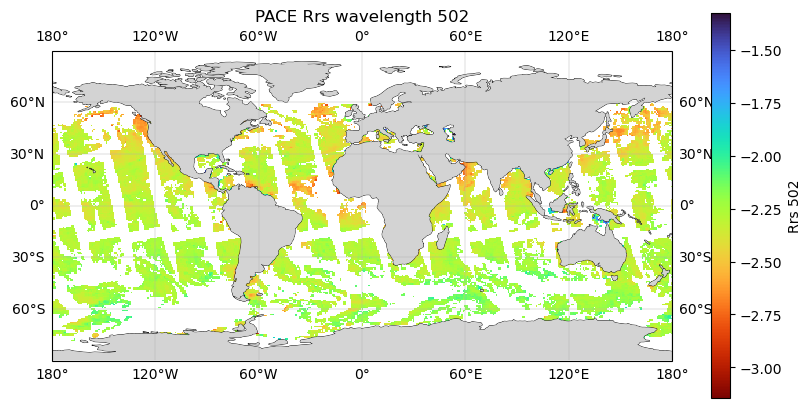

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

da_small = ds["Rrs"].sel(time="2026-02-05", wavelength=502).coarsen(
    lat=8,
    lon=8,
    boundary="trim",
).mean().compute()

log_chl = np.log10(da_small.where(da_small > 0))

fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

log_chl.plot(
    ax=ax,
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    cmap="turbo_r",
    cbar_kwargs={"label": "Rrs 502"},
)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
ax.set_global()
ax.gridlines(draw_labels=True, linewidth=0.3)

plt.title("PACE Rrs wavelength 502")
plt.show()

## PACE CHL

The daily data has subgroups for the different chunks before and after 2026-02. We need to merge these.

In [2]:
%%time
# Concat the groups
ds512 = create_ds("PACE_OCI_L3M_CHL", "daily/0p1deg/chunks_512")
ds16 = create_ds("PACE_OCI_L3M_CHL", "daily/0p1deg/chunks_16")

ds = xr.concat(
    [ds512, ds16],
    dim="time",
    coords="minimal",
    compat="override",
    combine_attrs="override",
).sortby("time")

ds

CPU times: user 7.14 s, sys: 603 ms, total: 7.74 s
Wall time: 14.5 s


<xarray.Dataset> Size: 18GB
Dimensions:  (time: 710, lat: 1800, lon: 3600, rgb: 3, eightbitcolor: 256)
Coordinates:
  * time     (time) datetime64[ns] 6kB 2024-03-05 2024-03-06 ... 2026-02-28
  * lat      (lat) float32 7kB 89.95 89.85 89.75 89.65 ... -89.75 -89.85 -89.95
  * lon      (lon) float32 14kB -179.9 -179.9 -179.8 ... 179.8 179.9 180.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    chlor_a  (time, lat, lon) float32 18GB dask.array<chunksize=(1, 16, 1024), meta=np.ndarray>
    palette  (time, rgb, eightbitcolor) uint8 545kB dask.array<chunksize=(1, 3, 256), meta=np.ndarray>
Attributes: (12/64)
    product_name:                      PACE_OCI.20260131.L3m.DAY.CHL.V3_1.chl...
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    identifier_product_doi:            10.5067/PACE/OCI/L3M/CHL/3.1
    keywords:                          Earth Science > Oceans > Ocean Chemist...
    keywords_vocabulary:               NASA Global Change Master Directory (G...
    data_bins:                         901994
    data_minimum:                      0.0030028503388166428
    data_maximum:                      98.65338897705078

## Make a plot


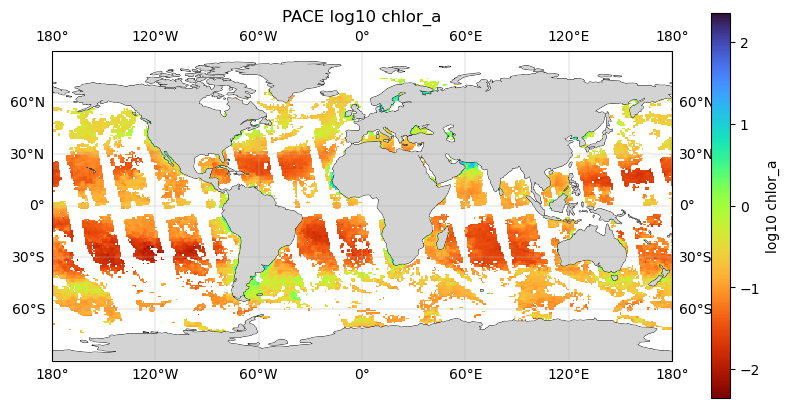

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

da_small = ds["chlor_a"].isel(time=10).coarsen(
    lat=8,
    lon=8,
    boundary="trim",
).mean().compute()

log_chl = np.log10(da_small.where(da_small > 0))

fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

log_chl.plot(
    ax=ax,
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    cmap="turbo_r",
    cbar_kwargs={"label": "log10 chlor_a"},
)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
ax.set_global()
ax.gridlines(draw_labels=True, linewidth=0.3)

plt.title("PACE log10 chlor_a")
plt.show()

## Time series at a point

Box is in the North Arabian Sea.

CPU times: user 12.8 s, sys: 1.03 s, total: 13.8 s
Wall time: 23.7 s


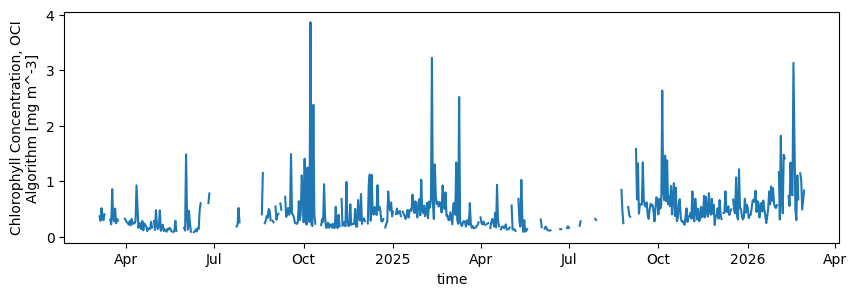

In [7]:
%%time
bbox = ds["chlor_a"].sel(
    lon=slice(65, 75),
    lat=slice(20, 10),
)

ts = bbox.mean(("lat", "lon")).compute()

ts.plot(figsize=(10, 3));

## Monthly averages

CPU times: user 15.2 s, sys: 1.19 s, total: 16.4 s
Wall time: 19.7 s


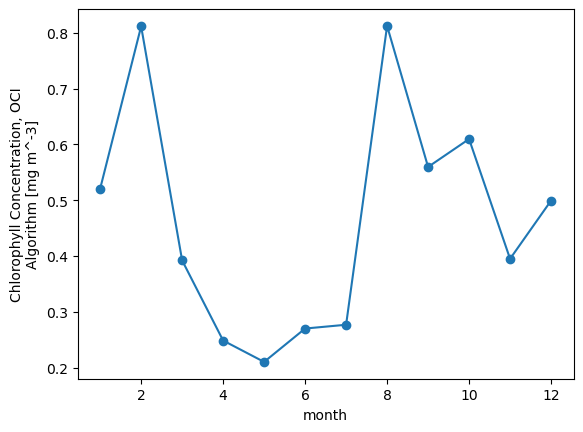

In [8]:
%%time
clim = (
    ds["chlor_a"]
    .sel(lon=slice(65, 75), lat=slice(20, 10))
    .mean(("lat", "lon"))
    .groupby("time.month")
    .mean()
    .compute()
)

clim.plot(marker="o");